# Spectral classification

## Imports

In [1]:
import sys
sys.path.append('/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject')
sys.path.append('/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject/ModelFitting')

import os
import matplotlib.pyplot as plt
from functions import vandermeer_lines, import_spectra, extract_spectrum_within_range
from ModelFitting.model_functions import important_spectral_lines
import numpy as np
from astropy.io import fits

In [2]:
# Global parameters
HOME = '/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject'
SPECTRAL_LINES = vandermeer_lines()
SPECTRAL_LINES = important_spectral_lines()
SPECTRAL_LINES = vandermeer_lines() + important_spectral_lines()

# Font sizes
TITLE = 8
LABEL = 14
AXIS = 10

# Important Spectral lines
HeII4541 = 4541 # Angstrom
HeI_II4026 = 4026
HeII4200 = 4200
HeI4471 = 4471

In [3]:
# Select the spectrum with the given wavelength
def select_spectrum(spectra: list, central_wav: float)->tuple:
    """
    Select the spectrum containing the given spectral line

    Args:
        spectra (list): List of spectra, made by import_spectra(object)
        central_wav (float): Central wavelenght of the spectral line

    Returns:
        tuple: wavelength, flux
    """
    for spectrum in spectra[::-1]:
        if central_wav >= min(spectrum[0])  and central_wav <= max(spectrum[0]):
            return spectrum[0], spectrum[1]



# Spectral lines in wavelength range
def spectral_lines_in_range(SPECTRAL_LINES, wavelength):
    # Define the range
    lower_bound = min(wavelength)
    upper_bound = max(wavelength)

    # Filter the list of tuples
    filtered_tuples = [tup for tup in SPECTRAL_LINES if lower_bound <= tup[0] <= upper_bound]

    return filtered_tuples



def find_closest_wavelength_indices(wavelength_values, wavelength_list):
    wavelength_array = np.array(wavelength_list)
    closest_indices = []
    for value in wavelength_values:
        closest_index = np.abs(wavelength_array - value).argmin()
        closest_indices.append(closest_index)
    return closest_indices



def plot_spectrum(wavelength: list, flux: list, object: str, save_name: str=False):
    # The spectral lines in the range of this spectrum
    lines = spectral_lines_in_range(SPECTRAL_LINES, wavelength)
    wavs = [tup[0] for tup in lines]
    names = [tup[1] for tup in lines]

    # Plot spectrum
    plt.figure(figsize=(14,5))
    plt.plot(wavelength, flux, color='black', linewidth=0.75)

    # Plot the spectral lines
    index = find_closest_wavelength_indices(wavs, wavelength)
    flux_low = flux[index]
    flux_high = flux[index] + (max(flux) / 5)
    plt.vlines(wavs, ymin=flux_low, ymax=flux_high, color='black', alpha=0.5)

    # Annotate each line with text vertically
    for (x, y, name) in zip(wavs, flux_high, names):
        plt.text(x, y + max(flux) / 100, name, ha='center', va='bottom', rotation=90, size=7)

    # Labels
    plt.ylabel(r'$F_{\lambda}$ (erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$)', fontsize=LABEL)
    plt.xlabel(r'$\lambda$ ($\AA$)', fontsize=LABEL)
    plt.title(f"{object}", fontsize=TITLE)

    # Axis
    plt.xticks(np.arange(round(min(wavelength), -2), max(wavelength), 100), fontsize=AXIS)
    plt.yticks(fontsize=AXIS)
    plt.ylim(bottom=0, top=1.25 * max(flux))
    plt.xlim(left=min(wavelength), right=max(wavelength))

    plt.tight_layout()

    # Save figure
    if save_name:
        plt.savefig(HOME + '/Plots/' + save_name)

    plt.show()



# Extract the spectrum within given wavelenght range
def extract_spectrum_within_range(wavelengths: np.array, flux: np.array, start_wavelength: float, end_wavelength: float)->tuple:
    """
    Extract wavelength and flux values within a given range.

    Parameters:
    - wavelengths: List or array of wavelength values.
    - flux: List or array of flux values.
    - start_wavelength: Lower bound of the wavelength range.
    - end_wavelength: Upper bound of the wavelength range.

    Returns:
    - extracted_wavelengths: Wavelength values within the specified range.
    - extracted_flux: Flux values corresponding to the selected wavelengths.
    """

    # Find indices corresponding to the specified wavelength range
    indices = np.where((wavelengths >= start_wavelength) & (wavelengths <= end_wavelength))[0]

    # Extract wavelength and flux values within the range
    extracted_wavelengths = wavelengths[indices]
    extracted_flux = flux[indices]

    return extracted_wavelengths, extracted_flux



# Selection of spectral lines and their ranges
def lines(object_name:str)->dict:
    """
    Returns a dictionary with the spectral lines and their ranges that
    will be used in the model fitting.

    Args:
        object_name (str): Name of the object you want the lines for.

    Returns:
        dict: lines: [wavelength, name, continuum left, line left, line right, continuum right]
              doppler_guess: #
    """
    # List with the lines that are appropriate to fit a gauss
    # lines: [wavelength, name, continuum left, line left, line right, continuum right]
    _4U1538_52 = {
        'lines': [
            [4340.46, r"H$\gamma$: 4340.46", 4325, 4335, 4340.7, 4347],
            [4387.93, r"He I: 4387.93", 4381, 4383.75, 4388.20, 4393],
            [4471.50, r"He I: 4471.50", 4459, 4466.2, 4472, 4477.5],
            [4713.17, r"He I: 4713.17", 4703, 4708.5, 4713, 4717],
            [4861.33, r"H$\beta$: 4861.33", 4845, 4854.5, 4862, 4870], 
            [4921.93, r"He I: 4921.93", 4910, 4916, 4922.4, 4932],
            [5015.68, r"He I: 5015.68", 5000, 5010.4, 5016, 5024],
        ],
        'Doppler_guess': 2.8
    }

    _CenX_3 = {
        'lines': [
            [4199.83, r"He II: 4199.83", 4191, 4196.8, 4204, 4210],
            [4026.21, r"He I: 4026.21", 4020, 4022, 4030, 4031.5]
        ],
        'Doppler_guess': 0
    }

    _SMCX_1 = {
        'lines': [
            [4026.21, r"He I: 4026.21", 4024, 4025.75, 4031.5, 4035]
        ],
        'Doppler_guess': -3.5
    }

    _4U1700_37 = {
        'lines': [
            [4026.21, r"He I: 4026.21", 4019.5, 4021.5, 4027.75, 4030.5],
            [4199.83, r"He II: 4199.83", 4195.5, 4196.6, 4201.9, 4204],
            [4541, r"He II 4541", 4535.4, 4536.4, 4544.25, 4545]
        ],
        'Doppler_guess': 0.6
    }

    _LMCX_4 = {
        'lines': [
            [4471.50, r"He I: 4471.50", 4467, 4472.3, 4480.5, 4485],
            [4026.21, r"He I: 4026.21", 4022.5, 4025, 4034.5, 4036]

        ],
        'Doppler_guess': -5
    }

    _VelaX_1 = {
        'lines': [
            [4199.83, r"He II: 4199.83", 4197.55, 4198, 4201.6, 4203]
        ],
        'Doppler_guess': 0.3
    }

    line_dict = {'4U1538-52': _4U1538_52, 'Cen X-3': _CenX_3, 'SMC X-1': _SMCX_1,
                 '4U1700-37': _4U1700_37, 'LMC X-4': _LMCX_4, 'Vela X-1': _VelaX_1}

    return line_dict[object_name]

In [4]:
# Get all the folder names in the spectra folder
subfolders = [f.name for f in os.scandir(HOME + '/Spectra') if f.is_dir()]

# Make a dictionary of all the spectra
spectra = {}
for folder in subfolders:
    spectra[folder] = import_spectra(folder)

Spectrum for LMCX_4 is FLUX REDUCED


## Classification

### 4U1700-37

Spectral type: O6Iaf+ (van der Meer)

He II 4541: Present, so O star;

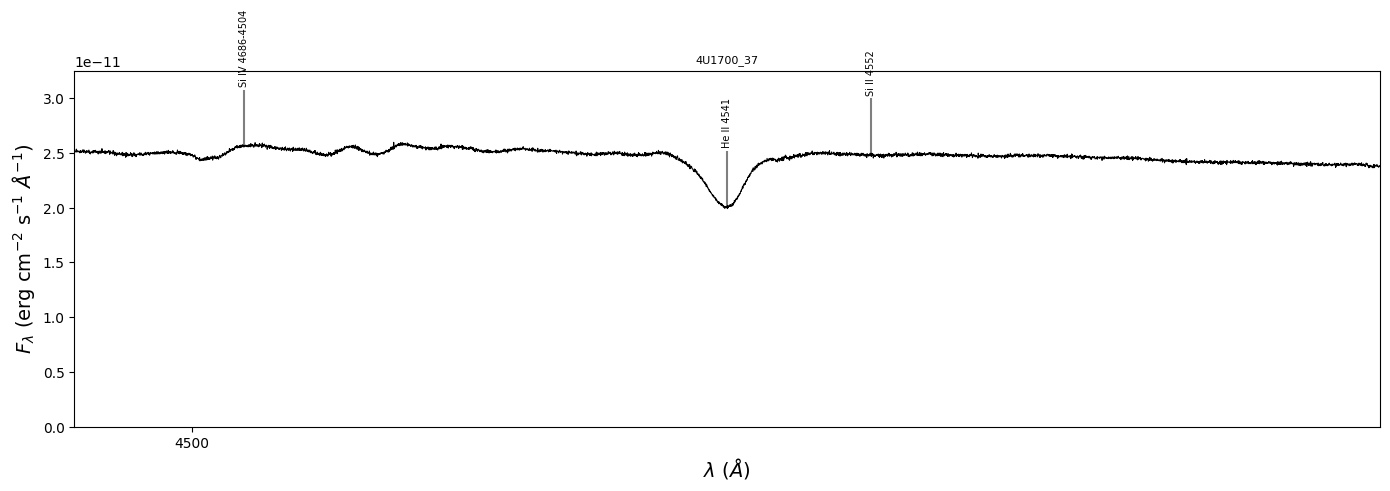

In [5]:
object_name = '4U1700_37'
wavelength, flux = select_spectrum(spectra[object_name], HeII4541)
wavelength, flux = extract_spectrum_within_range(wavelength, flux, HeII4541-50, HeII4541+50)

plot_spectrum(wavelength, flux * 10E-16, object_name)

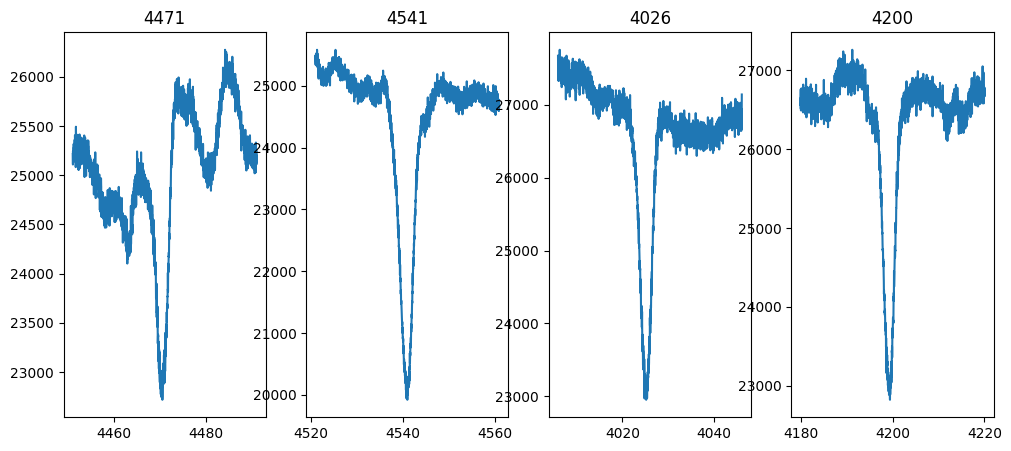

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(12,5))

line_list = [HeI4471, HeII4541, HeI_II4026, HeII4200]
for ax, line in zip(axes, line_list):

    wavelength, flux = select_spectrum(spectra[object_name], HeII4541)
    wavelength, flux = extract_spectrum_within_range(wavelength, flux, line-20, line+20)

    ax.plot(wavelength, flux)
    ax.set_title(f"{line}")

plt.tight_layout()
plt.show()

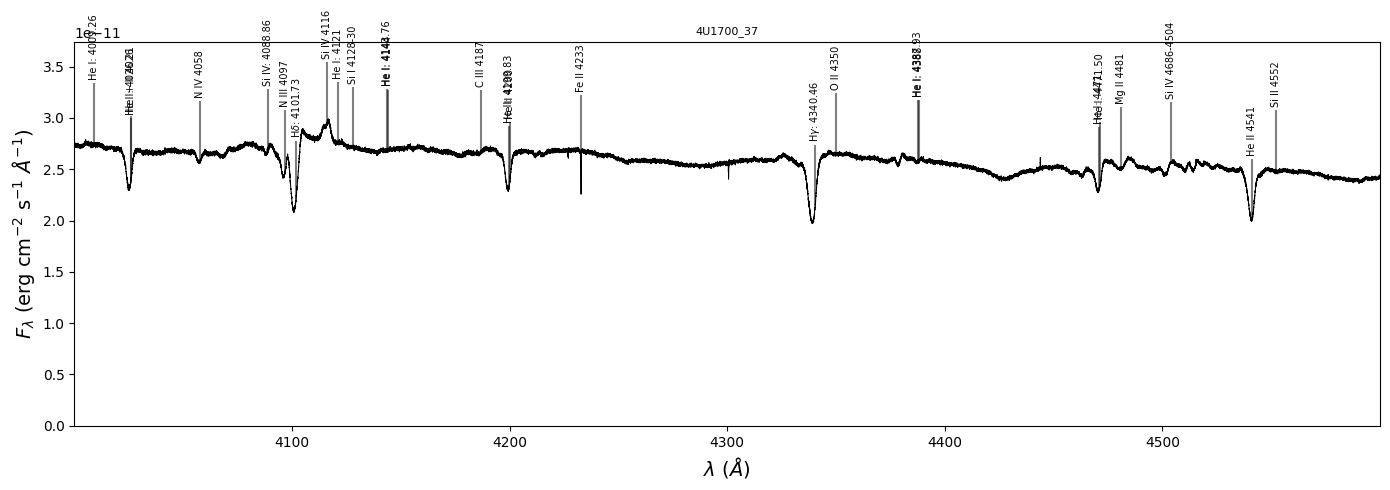

In [9]:
object_name = '4U1700_37'
wavelength, flux = select_spectrum(spectra[object_name], HeII4541)
wavelength, flux = extract_spectrum_within_range(wavelength, flux, 4000, 4600)

plot_spectrum(wavelength, flux * 10E-16, object_name)